In [1]:
!pip install ipython-autotime
%load_ext autotime

time: 173 μs (started: 2026-04-02 17:20:52 +00:00)


In [2]:
!nvidia-smi

Thu Apr  2 17:20:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   77C    P0             37W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch
import math


def swa_naive(q, k, v, window_sizes: tuple[int, int] = (15, 16)):
    """
    Naive implementation of sliding window attention.

    Parameters
    ----------
    q : (..., L, Dqk) torch.Tensor
        Queries to compute attention with.
    k : (..., L, Dqk) torch.Tensor
        Keys to compute attention with.
    v : (..., L, Dv) torch.Tensor
        Values to compute attention with.
    window_sizes : tuple[int, int]
        The number of time-steps to look back- and forward, in that order.
        Causal masking is enabled when the second value is zero.

    Returns
    -------
    h : (..., L, Dv) torch.Tensor
        The computed output sequence.
    """
    bwd_win_size, fwd_win_size = window_sizes

    row_idx = torch.arange(q.shape[-2], device=q.device).unsqueeze(-1)
    col_idx = torch.arange(k.shape[-2], device=k.device).unsqueeze(-2)
    fwd_inv_mask = row_idx < col_idx - fwd_win_size
    bwd_inv_mask = row_idx > col_idx + bwd_win_size

    qk = q @ k.transpose(-1, -2)
    qk = qk / math.sqrt(q.shape[-1])
    qk_masked = torch.masked_fill(qk, fwd_inv_mask | bwd_inv_mask, -float("inf"))
    a = torch.softmax(qk_masked, dim=-1)
    return a @ v


def swa_strided(q, k, v, window_sizes: tuple[int, int] = (15, 16)):
    """
    Sliding window attention implemented using striding tricks.
    """
    bwd_win_size, fwd_win_size = window_sizes
    win_size = 1 + bwd_win_size + fwd_win_size
    assert win_size < k.shape[-2]

    k_to_pad = [k.ravel()]
    v_to_pad = [v.ravel()]
    if bwd_win_size > 0:
        k_to_pad.insert(0, torch.zeros(bwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.insert(0, torch.zeros(bwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))
    if fwd_win_size > 0:
        k_to_pad.append(torch.zeros(fwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.append(torch.zeros(fwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))

    k_strided = torch.as_strided(
        torch.cat(k_to_pad, dim=0),
        size=(*k.shape[:-1], win_size, k.shape[-1]),
        stride=(*k.stride()[:-1], k.stride(-2), k.stride(-1))
    )
    v_strided = torch.as_strided(
        torch.cat(v_to_pad, dim=0),
        size=(*v.shape[:-1], win_size, v.shape[-1]),
        stride=(*v.stride()[:-1], v.stride(-2), v.stride(-1))
    )

    row_idx = torch.arange(q.shape[-2], device=q.device).unsqueeze(-1)
    col_idx = torch.arange(-bwd_win_size, fwd_win_size + 1, device=q.device).unsqueeze(-2)
    fwd_inv_mask = row_idx < -col_idx
    bwd_inv_mask = q.shape[-2] - 1 - row_idx < col_idx

    qk = torch.sum(q.unsqueeze(-2) * k_strided, dim=-1)
    qk = qk / math.sqrt(q.shape[-1])
    qk_masked = torch.masked_fill(qk, fwd_inv_mask | bwd_inv_mask, -float("inf"))
    a = torch.softmax(qk_masked, dim=-1)
    return torch.sum(a.unsqueeze(-1) * v_strided, dim=-2)

time: 1.58 s (started: 2026-04-02 17:21:01 +00:00)


In [4]:
batch_size = 2
num_heads = 8
seq_len = 128
d_qk = 64
d_v = 64

device = 'cuda' if torch.cuda.is_available() else 'cpu'

q = torch.randn(batch_size, num_heads, seq_len, d_qk, device=device, dtype=torch.float32)
k = torch.randn(batch_size, num_heads, seq_len, d_qk, device=device, dtype=torch.float32)
v = torch.randn(batch_size, num_heads, seq_len, d_v, device=device, dtype=torch.float32)

window_sizes = (15, 16)

output_naive = swa_naive(q, k, v, window_sizes=window_sizes)
output_strided = swa_strided(q, k, v, window_sizes=window_sizes)

is_close = torch.allclose(output_naive, output_strided, atol=1e-3, rtol=1e-3)

print(f"Is close: {is_close}")

print(f"Input shape: {q.shape}")
print(f"Output shape: {output_naive.shape}")
print(f"Output sample:\n{output_naive[0, 0, :5, :5]}")

Is close: True
Input shape: torch.Size([2, 8, 128, 64])
Output shape: torch.Size([2, 8, 128, 64])
Output sample:
tensor([[ 0.0748, -0.3973, -0.4215,  0.2621,  0.2335],
        [ 0.1988, -0.7482,  0.1512,  0.6141, -0.2994],
        [-0.0102, -0.3454, -0.0257,  0.1535,  0.2557],
        [ 0.0315, -0.6631,  0.3094,  0.2773,  0.0564],
        [-0.1998, -0.4282,  0.3234,  0.0114, -0.0790]], device='cuda:0')
time: 2.05 s (started: 2026-04-02 17:21:02 +00:00)


### Visualize Sliding Windows Attention

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def visualize_sliding_attention(L=20, bwd_win=3, fwd_win=2):
    mask = np.zeros((L, L))

    for i in range(L):
        for j in range(L):
            if (i - bwd_win) <= j <= (i + fwd_win):
                mask[i, j] = 1  # valid attention

    plt.figure()
    plt.imshow(mask)
    plt.xlabel("Key index j")
    plt.ylabel("Query index i")
    plt.title(f"Sliding Window Attention (bwd={bwd_win}, fwd={fwd_win})")
    plt.show()

time: 404 ms (started: 2026-04-02 17:21:04 +00:00)


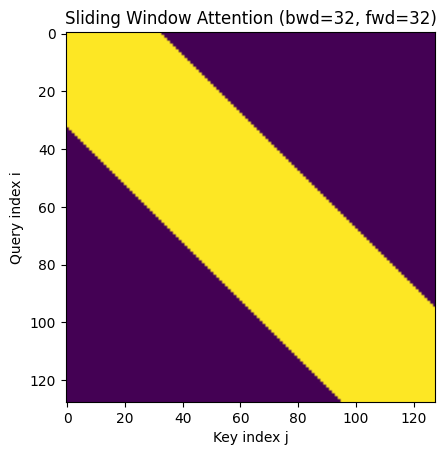

time: 163 ms (started: 2026-04-02 17:21:05 +00:00)


In [6]:
visualize_sliding_attention(
    L=128,
    bwd_win=32,
    fwd_win=32
)

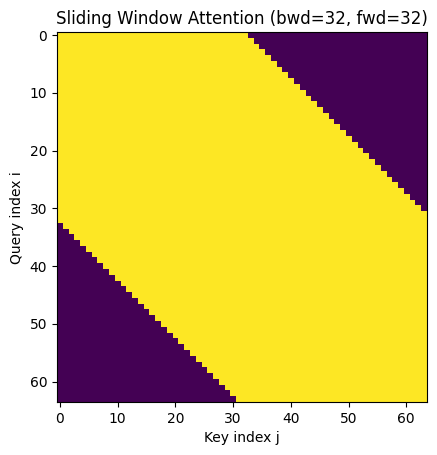

time: 124 ms (started: 2026-04-02 17:21:05 +00:00)


In [7]:
visualize_sliding_attention(
    L=64,
    bwd_win=32,
    fwd_win=32
)

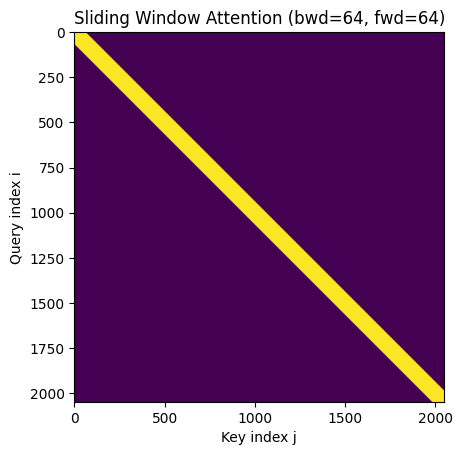

time: 1.08 s (started: 2026-04-02 17:21:05 +00:00)


In [8]:
visualize_sliding_attention(
    L=2048,
    bwd_win=64,
    fwd_win=64
)

### Triton Kernel

In [9]:
import torch
import math
import triton
import triton.language as tl

time: 108 ms (started: 2026-04-02 17:21:06 +00:00)


In [10]:
@triton.autotune(
    configs=[
        triton.Config({'BLOCK_M': 32, 'BLOCK_N': 32}, num_warps=4),
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 32}, num_warps=4),
        triton.Config({'BLOCK_M': 64,'BLOCK_N': 64}, num_warps=8),
        triton.Config({'BLOCK_M': 128,'BLOCK_N': 64}, num_warps=8),
        triton.Config({'BLOCK_M': 128,'BLOCK_N': 128}, num_warps=8),
    ],
    key=['N_CTX']
)
@triton.jit
def swa_triton_kernel(
    Q, 
    K, 
    V, 
    Out,
    stride_qb, 
    stride_qh, 
    stride_qm, 
    stride_qk,
    stride_kb, 
    stride_kh, 
    stride_km, 
    stride_kk,
    stride_vb, 
    stride_vh, 
    stride_vm, 
    stride_vk,
    stride_ob, 
    stride_oh, 
    stride_om, 
    stride_ok,
    Z,
    H,
    N_CTX,
    sm_scale,
    BWD_WINDOW: tl.constexpr,
    FWD_WINDOW: tl.constexpr,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_DMODEL: tl.constexpr,
):
    start_m = tl.program_id(0)
    off_hz = tl.program_id(1)
    
    off_b = off_hz // H
    off_h = off_hz % H

    q_offset = off_b * stride_qb + off_h * stride_qh
    k_offset = off_b * stride_kb + off_h * stride_kh
    v_offset = off_b * stride_vb + off_h * stride_vh
    o_offset = off_b * stride_ob + off_h * stride_oh

    offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = tl.arange(0, BLOCK_N)
    offs_d = tl.arange(0, BLOCK_DMODEL)

    q_ptrs = Q + q_offset + offs_m[:, None] * stride_qm + offs_d[None, :] * stride_qk
    o_ptrs = Out + o_offset + offs_m[:, None] * stride_om + offs_d[None, :] * stride_ok

    q_mask = offs_m[:, None] < N_CTX
    q = tl.load(q_ptrs, mask=q_mask, other=0.0)

    m_i = tl.full([BLOCK_M], -float("inf"), dtype=tl.float32)
    l_i = tl.zeros([BLOCK_M], dtype=tl.float32)
    acc = tl.zeros([BLOCK_M, BLOCK_DMODEL], dtype=tl.float32)

    start_n_iter = tl.maximum(0, (start_m * BLOCK_M - BWD_WINDOW) // BLOCK_N)
    end_n_iter = tl.minimum((N_CTX + BLOCK_N - 1) // BLOCK_N, ((start_m + 1) * BLOCK_M + FWD_WINDOW + BLOCK_N - 1) // BLOCK_N)

    for n_iter in range(start_n_iter, end_n_iter):
        curr_n = n_iter * BLOCK_N + offs_n
        
        k_ptrs = K + k_offset + offs_d[:, None] * stride_kk + curr_n[None, :] * stride_km
        v_ptrs = V + v_offset + curr_n[:, None] * stride_vm + offs_d[None, :] * stride_vk
        
        k_mask = curr_n[None, :] < N_CTX
        v_mask = curr_n[:, None] < N_CTX
        
        k = tl.load(k_ptrs, mask=k_mask, other=0.0)
        v = tl.load(v_ptrs, mask=v_mask, other=0.0)

        qk = tl.zeros([BLOCK_M, BLOCK_N], dtype=tl.float32)
        qk += tl.dot(q, k)
        qk = qk * sm_scale

        dist = offs_m[:, None] - curr_n[None, :]
        in_window = (dist <= BWD_WINDOW) & (dist >= -FWD_WINDOW) & (curr_n[None, :] < N_CTX)
        qk = tl.where(in_window, qk, -float("inf"))

        m_ij = tl.maximum(m_i, tl.max(qk, 1))
        
        # replace -inf with 0.0 to prevent NaN generation
        m_ij_safe = tl.where(m_ij == -float("inf"), 0.0, m_ij)
        m_i_safe = tl.where(m_i == -float("inf"), 0.0, m_i)
        
        p = tl.exp(qk - m_ij_safe[:, None])
        l_ij = tl.sum(p, 1)

        alpha = tl.exp(m_i_safe - m_ij_safe)
        alpha = tl.where(m_i == -float("inf"), 0.0, alpha)

        l_i = l_i * alpha + l_ij
        acc = acc * alpha[:, None]
        acc += tl.dot(p.to(v.dtype), v)

        m_i = m_ij

    acc = acc / l_i[:, None]
    tl.store(o_ptrs, acc.to(Out.dtype.element_ty), mask=q_mask)

time: 99 ms (started: 2026-04-02 17:21:06 +00:00)


In [11]:
import torch
import triton
import math

def run_swa_triton(q, k, v, window_sizes=(15, 16)):

    batch_size, num_heads, seq_len, d_qk = q.shape
    _, _, _, d_v = v.shape

    bwd_win, fwd_win = window_sizes

    sm_scale = 1.0 / math.sqrt(d_qk)

    out = torch.empty(
        (batch_size, num_heads, seq_len, d_v),
        device=q.device,
        dtype=q.dtype,
    )

    BLOCK_DMODEL = triton.next_power_of_2(d_qk)

    grid = lambda META: (
        triton.cdiv(seq_len, META['BLOCK_M']),
        batch_size * num_heads
    )

    swa_triton_kernel[grid](
        q,
        k,
        v,
        out,
        q.stride(0), 
        q.stride(1), 
        q.stride(2), 
        q.stride(3),
        k.stride(0), 
        k.stride(1),
        k.stride(2), 
        k.stride(3),
        v.stride(0), 
        v.stride(1), 
        v.stride(2), 
        v.stride(3),
        out.stride(0), 
        out.stride(1), 
        out.stride(2), 
        out.stride(3),
        batch_size,
        num_heads,
        seq_len,
        sm_scale,
        BWD_WINDOW=bwd_win,
        FWD_WINDOW=fwd_win,
        BLOCK_DMODEL=BLOCK_DMODEL,
    )

    return out

time: 1.77 ms (started: 2026-04-02 17:21:06 +00:00)


In [12]:
import triton


torch.manual_seed(1374)

batch_size = 2
num_heads = 8
seq_len = 128
d_qk = 64
d_v = 64

device = 'cuda' if torch.cuda.is_available() else 'cpu'

q = torch.randn(batch_size, num_heads, seq_len, d_qk, device=device, dtype=torch.float32)
k = torch.randn(batch_size, num_heads, seq_len, d_qk, device=device, dtype=torch.float32)
v = torch.randn(batch_size, num_heads, seq_len, d_v, device=device, dtype=torch.float32)

window_sizes = (15, 16)

output_triton = run_swa_triton(q, k, v, window_sizes=window_sizes)
output_strided = swa_strided(q, k, v, window_sizes=window_sizes)

is_close = torch.allclose(output_triton, output_strided, atol=5e-3, rtol=1e-3)

print(f"Is close: {is_close}\n")
print(f"Input shape: {q.shape}")
print(f"Output shape: {output_triton.shape}")
print(f"Output sample (Triton):\n{output_triton[0, 0, :5, :5]}\n")

max_diff = torch.max(torch.abs(output_triton - output_strided)).item()
mean_diff = torch.mean(torch.abs(output_triton - output_strided)).item()
mse = torch.nn.functional.mse_loss(output_triton, output_strided).item()

print(f"Max Absolute Difference: {max_diff:.8f}")
print(f"Mean Absolute Difference: {mean_diff:.8f}")
print(f"Mean Squared Error:      {mse:.8f}")

Is close: True

Input shape: torch.Size([2, 8, 128, 64])
Output shape: torch.Size([2, 8, 128, 64])
Output sample (Triton):
tensor([[-0.2238,  0.2291,  0.2221, -0.0856,  0.6211],
        [-0.0631,  0.0372,  0.4105,  0.2491,  0.2451],
        [ 0.2242,  0.3480,  0.1470,  0.5378,  0.1681],
        [ 0.1557,  0.3562,  0.4599,  0.4524,  0.3701],
        [-0.2544, -0.0971,  0.2218,  0.4441,  0.0571]], device='cuda:0')

Max Absolute Difference: 0.00280201
Mean Absolute Difference: 0.00024487
Mean Squared Error:      0.00000010
time: 2.84 s (started: 2026-04-02 17:21:06 +00:00)


In [13]:
import torch
import triton
import triton.testing

torch.manual_seed(1374)

batch_size = 2
num_heads = 8
seq_len = 128
d_qk = 64
d_v = 64

device = 'cuda' if torch.cuda.is_available() else 'cpu'

q = torch.randn(batch_size, num_heads, seq_len, d_qk, device=device, dtype=torch.float32)
k = torch.randn(batch_size, num_heads, seq_len, d_qk, device=device, dtype=torch.float32)
v = torch.randn(batch_size, num_heads, seq_len, d_v, device=device, dtype=torch.float32)

window_sizes = (15, 16)

for _ in range(10):
    run_swa_triton(q, k, v, window_sizes=window_sizes)
    swa_strided(q, k, v, window_sizes=window_sizes)

torch.cuda.synchronize()

triton_ms = triton.testing.do_bench(
    lambda: run_swa_triton(q, k, v, window_sizes=window_sizes)
)

strided_ms = triton.testing.do_bench(
    lambda: swa_strided(q, k, v, window_sizes=window_sizes)
)

print(f"Triton implementation : {triton_ms:.4f} ms")
print(f"Strided PyTorch       : {strided_ms:.4f} ms")

speedup = strided_ms / triton_ms
print(f"Speedup (Triton vs PyTorch): {speedup:.2f}x")

Triton implementation : 0.0173 ms
Strided PyTorch       : 0.1779 ms
Speedup (Triton vs PyTorch): 10.30x
time: 233 ms (started: 2026-04-02 17:21:09 +00:00)


### Benchmark

In [14]:
import torch
import triton
import triton.testing
import math

DEVICE = 'cuda'

batch_size = 2
num_heads = 8
d_qk = 64
d_v = 64
window_sizes = (15, 16)

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['seq_len'],
        x_vals=[2**i for i in range(6, 12)],  # 64 to 16K
        x_log=True,
        line_arg='provider',
        line_vals=['triton', 'strided', 'naive'],
        line_names=[
            'Triton SWA',
            'Torch Strided SWA',
            'Torch Naive SWA'
        ],
        styles=[
            ('blue', '-'),
            ('green', '-'),
            ('red', '-')
        ],
        ylabel='TFLOPS',
        plot_name='swa-performance',
        args={}
    )
)
def benchmark(seq_len, provider):

    q = torch.randn(batch_size, num_heads, seq_len, d_qk, device=DEVICE)
    k = torch.randn(batch_size, num_heads, seq_len, d_qk, device=DEVICE)
    v = torch.randn(batch_size, num_heads, seq_len, d_v, device=DEVICE)

    quantiles = [0.5, 0.2, 0.8]

    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: run_swa_triton(q, k, v, window_sizes=window_sizes),
            quantiles=quantiles
        )

    if provider == 'strided':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: swa_strided(q, k, v, window_sizes=window_sizes),
            quantiles=quantiles
        )

    if provider == 'naive':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: swa_naive(q, k, v, window_sizes=window_sizes),
            quantiles=quantiles
        )

    # approximate FLOPs
    window = window_sizes[0] + window_sizes[1] + 1
    flops = 2 * batch_size * num_heads * seq_len * window * d_qk

    perf = lambda ms: flops * 1e-12 / (ms * 1e-3)

    return perf(ms), perf(max_ms), perf(min_ms)

time: 2 ms (started: 2026-04-02 17:21:09 +00:00)


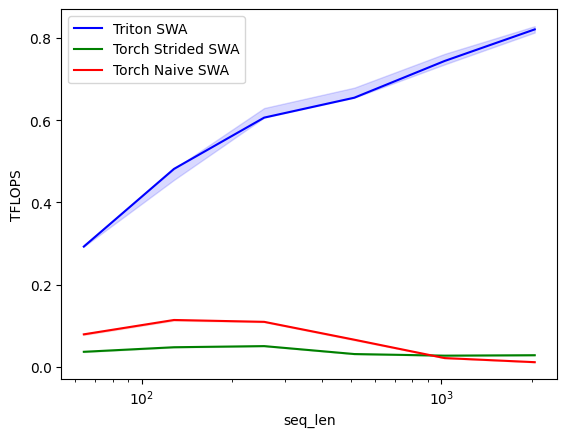

swa-performance:
   seq_len  Triton SWA  Torch Strided SWA  Torch Naive SWA
0     64.0    0.292571           0.036248         0.078769
1    128.0    0.481882           0.047353         0.113778
2    256.0    0.606815           0.050104         0.109227
3    512.0    0.655360           0.030768         0.065667
4   1024.0    0.744727           0.026859         0.020975
5   2048.0    0.821768           0.027935         0.010953
time: 4.73 s (started: 2026-04-02 17:21:10 +00:00)


In [15]:
benchmark.run(print_data=True, show_plots=True)

### Strided Triton Kernel

  SWA Strided — Full Dimension Sweep (TFLOPS)
  GPU: NVIDIA L4    dtype default: torch.float16

──────────────────────────────────────────────────────────────────────
  Sweep: Sequence Length
──────────────────────────────────────────────────────────────────────
sweep_seq_len_tflops:
     N_CTX  PyTorch (strided)  Triton (strided)
0    256.0           0.140635          0.143719
1    512.0           0.139736          0.196216
2   1024.0           0.096023          0.249186
3   2048.0           0.090991          0.281573
4   4096.0           0.093832          0.295290
5   8192.0           0.082738          0.301445
6  16384.0           0.074616          0.253187

──────────────────────────────────────────────────────────────────────
  Sweep: Batch Size
──────────────────────────────────────────────────────────────────────
sweep_batch_size_tflops:
      B  PyTorch (strided)  Triton (strided)
0   1.0           0.099223          0.252062
1   2.0           0.095100          0.279471
2   4.0 

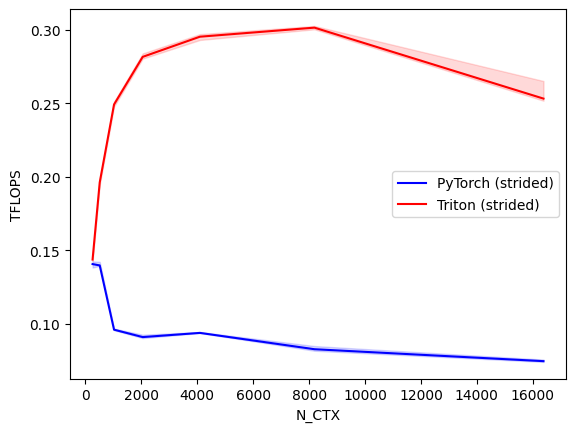

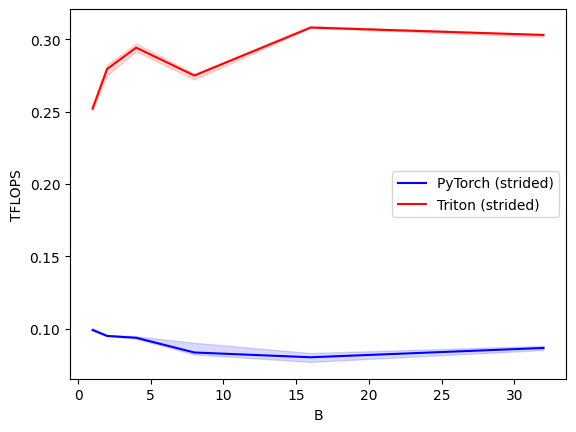

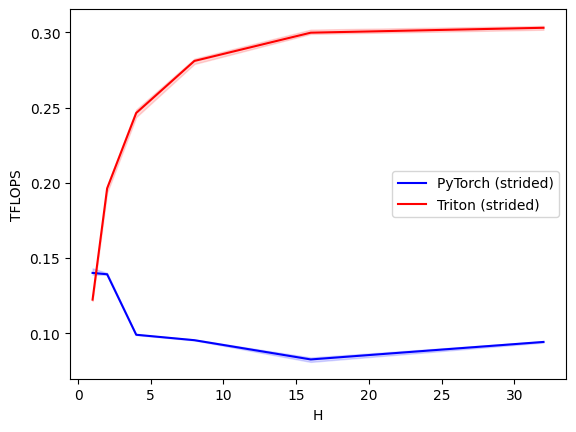

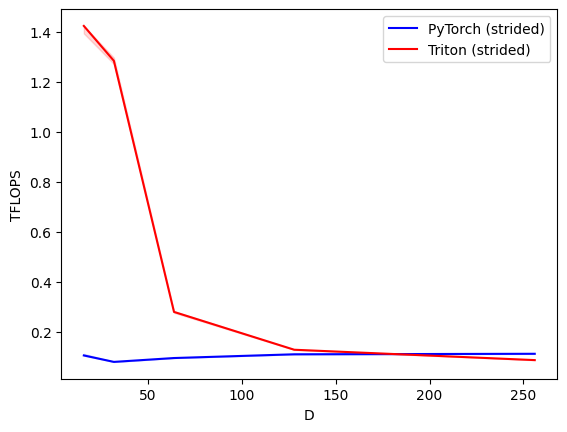

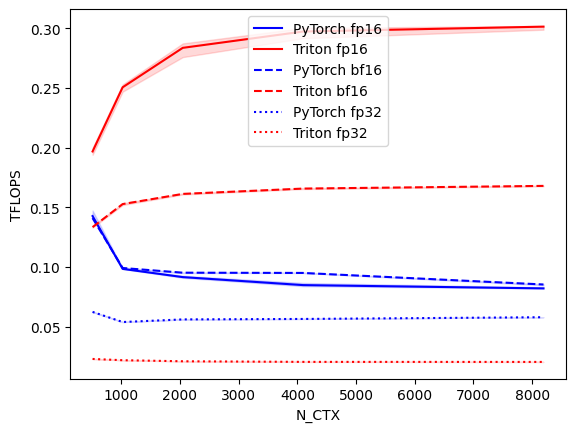

time: 3min 20s (started: 2026-04-02 16:59:40 +00:00)


In [17]:
import math
import torch
import triton
import triton.language as tl
import os


def swa_strided_pytorch(q, k, v, window_sizes: tuple[int, int] = (15, 16)):
    bwd_win_size, fwd_win_size = window_sizes
    win_size = 1 + bwd_win_size + fwd_win_size

    k_to_pad = [k.ravel()]
    v_to_pad = [v.ravel()]
    if bwd_win_size > 0:
        k_to_pad.insert(0, torch.zeros(bwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.insert(0, torch.zeros(bwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))
    if fwd_win_size > 0:
        k_to_pad.append(torch.zeros(fwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.append(torch.zeros(fwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))

    k_strided = torch.as_strided(
        torch.cat(k_to_pad, dim=0),
        size=(*k.shape[:-1], win_size, k.shape[-1]),
        stride=(*k.stride()[:-1], k.stride(-2), k.stride(-1)),
    )
    v_strided = torch.as_strided(
        torch.cat(v_to_pad, dim=0),
        size=(*v.shape[:-1], win_size, v.shape[-1]),
        stride=(*v.stride()[:-1], v.stride(-2), v.stride(-1)),
    )

    row_idx = torch.arange(q.shape[-2], device=q.device).unsqueeze(-1)
    col_idx = torch.arange(-bwd_win_size, fwd_win_size + 1, device=q.device).unsqueeze(-2)
    fwd_inv_mask = row_idx < -col_idx
    bwd_inv_mask = q.shape[-2] - 1 - row_idx < col_idx

    qk = torch.sum(q.unsqueeze(-2) * k_strided, dim=-1) / math.sqrt(q.shape[-1])
    qk_masked = torch.masked_fill(qk, fwd_inv_mask | bwd_inv_mask, -float("inf"))
    a = torch.softmax(qk_masked, dim=-1)
    return torch.sum(a.unsqueeze(-1) * v_strided, dim=-2)


@triton.autotune(
    configs=[
        triton.Config({"BLOCK_M": 32}, num_warps=4),
        triton.Config({"BLOCK_M": 64}, num_warps=4),
        triton.Config({"BLOCK_M": 64}, num_warps=8),
        triton.Config({"BLOCK_M": 128}, num_warps=8),
    ],
    key=["N_CTX"],
)
@triton.jit
def swa_strided_triton_kernel(
    Q, K, V, Out,
    stride_qb, stride_qh, stride_qm, stride_qk,
    stride_kb, stride_kh, stride_km, stride_kk,
    stride_vb, stride_vh, stride_vm, stride_vk,
    stride_ob, stride_oh, stride_om, stride_ok,
    Z, H, N_CTX,
    sm_scale,
    BWD_WINDOW: tl.constexpr,
    FWD_WINDOW: tl.constexpr,
    BLOCK_M: tl.constexpr,
    WIN_SIZE: tl.constexpr,
    BLOCK_DMODEL: tl.constexpr,
):
    start_m = tl.program_id(0)
    off_hz = tl.program_id(1)
    off_b = off_hz // H
    off_h = off_hz % H

    q_offset = off_b * stride_qb + off_h * stride_qh
    k_offset = off_b * stride_kb + off_h * stride_kh
    v_offset = off_b * stride_vb + off_h * stride_vh
    o_offset = off_b * stride_ob + off_h * stride_oh

    offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_d = tl.arange(0, BLOCK_DMODEL)
    offs_w = tl.arange(0, WIN_SIZE) - BWD_WINDOW

    q_ptrs = Q + q_offset + offs_m[:, None] * stride_qm + offs_d[None, :] * stride_qk
    q_mask = offs_m[:, None] < N_CTX
    q = tl.load(q_ptrs, mask=q_mask, other=0.0)

    kv_pos = offs_m[:, None] + offs_w[None, :]
    in_seq = (kv_pos >= 0) & (kv_pos < N_CTX)
    kv_pos_safe = tl.where(in_seq, kv_pos, 0)

    k_ptrs = (K + k_offset
              + kv_pos_safe[:, :, None] * stride_km
              + offs_d[None, None, :] * stride_kk)
    k_mask = in_seq[:, :, None]
    k_win = tl.load(k_ptrs, mask=k_mask, other=0.0)

    v_ptrs = (V + v_offset
              + kv_pos_safe[:, :, None] * stride_vm
              + offs_d[None, None, :] * stride_vk)
    v_win = tl.load(v_ptrs, mask=k_mask, other=0.0)

    qk = tl.sum(q[:, None, :] * k_win, axis=2)
    qk = qk * sm_scale
    qk = tl.where(in_seq, qk, -float("inf"))

    m_i = tl.max(qk, axis=1)
    m_safe = tl.where(m_i == -float("inf"), 0.0, m_i)
    p = tl.exp(qk - m_safe[:, None])
    p = tl.where(in_seq, p, 0.0)
    l_i = tl.sum(p, axis=1)

    acc = tl.sum(p[:, :, None] * v_win, axis=1)
    acc = acc / l_i[:, None]

    o_ptrs = Out + o_offset + offs_m[:, None] * stride_om + offs_d[None, :] * stride_ok
    tl.store(o_ptrs, acc.to(Out.dtype.element_ty), mask=q_mask)


def swa_strided_triton(q, k, v, bwd_window, fwd_window):
    B, H, N, D = q.shape
    out = torch.empty_like(q)
    sm_scale = 1.0 / math.sqrt(D)
    win_size = 1 + bwd_window + fwd_window
    WIN_SIZE_POW2 = triton.next_power_of_2(win_size)
    BLOCK_DMODEL = triton.next_power_of_2(D)

    grid = lambda META: (triton.cdiv(N, META["BLOCK_M"]), B * H)

    swa_strided_triton_kernel[grid](
        q, k, v, out,
        *q.stride(), *k.stride(), *v.stride(), *out.stride(),
        B, H, N,
        sm_scale,
        BWD_WINDOW=bwd_window,
        FWD_WINDOW=fwd_window,
        WIN_SIZE=WIN_SIZE_POW2,
        BLOCK_DMODEL=BLOCK_DMODEL,
    )
    return out


SAVE_DIR = "bench_results_full"
DTYPE = torch.float16
DEVICE = "cuda"
QUANTILES = [0.5, 0.2, 0.8]

PROVIDERS = ["pytorch", "triton_strided"]
NAMES     = ["PyTorch (strided)", "Triton (strided)"]
STYLES    = [("blue", "-"), ("red", "-")]


def swa_flops(B, H, N, D, W):
    return B * H * 4 * N * W * D


def ms_to_tflops(ms, flops):
    """Convert milliseconds to TFLOPS given total flop count."""
    return flops / (ms * 1e-3) / 1e12


def run_one(provider, q, k, v, bwd, fwd):
    if provider == "pytorch":
        fn = lambda: swa_strided_pytorch(q, k, v, window_sizes=(bwd, fwd))
    else:
        fn = lambda: swa_strided_triton(q, k, v, bwd, fwd)
    return triton.testing.do_bench(fn, quantiles=QUANTILES)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N_CTX"],
        x_vals=[2**i for i in range(8, 15)],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_seq_len_tflops",
        args={"B": 2, "H": 8, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_seq_len(N_CTX, provider, B, H, D, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["B"],
        x_vals=[1, 2, 4, 8, 16, 32],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_batch_size_tflops",
        args={"N_CTX": 2048, "H": 8, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_batch(B, provider, N_CTX, H, D, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["H"],
        x_vals=[1, 2, 4, 8, 16, 32],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_num_heads_tflops",
        args={"B": 2, "N_CTX": 2048, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_heads(H, provider, B, N_CTX, D, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["D"],
        x_vals=[16, 32, 64, 128, 256],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_head_dim_tflops",
        args={"B": 2, "H": 8, "N_CTX": 2048, "BWD": 15, "FWD": 16},
    )
)
def bench_head_dim(D, provider, B, H, N_CTX, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["WIN_HALF"],
        x_vals=[4, 8, 16, 32, 64, 128, 256],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_window_size_tflops",
        args={"B": 2, "H": 8, "N_CTX": 4096, "D": 64},
    )
)
def bench_window(WIN_HALF, provider, B, H, N_CTX, D):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, WIN_HALF, WIN_HALF)
    W = 1 + 2 * WIN_HALF
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N_CTX"],
        x_vals=[512, 1024, 2048, 4096, 8192],
        line_arg="provider",
        line_vals=["pytorch_fp16", "triton_fp16", "pytorch_bf16", "triton_bf16",
                    "pytorch_fp32", "triton_fp32"],
        line_names=["PyTorch fp16", "Triton fp16", "PyTorch bf16", "Triton bf16",
                     "PyTorch fp32", "Triton fp32"],
        styles=[("blue", "-"), ("red", "-"),
                ("blue", "--"), ("red", "--"),
                ("blue", ":"), ("red", ":")],
        ylabel="TFLOPS",
        plot_name="sweep_dtype_tflops",
        args={"B": 2, "H": 8, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_dtype(N_CTX, provider, B, H, D, BWD, FWD):
    dtype_map = {
        "pytorch_fp16": (torch.float16, "pytorch"),
        "triton_fp16":  (torch.float16, "triton_strided"),
        "pytorch_bf16": (torch.bfloat16, "pytorch"),
        "triton_bf16":  (torch.bfloat16, "triton_strided"),
        "pytorch_fp32": (torch.float32, "pytorch"),
        "triton_fp32":  (torch.float32, "triton_strided"),
    }
    dt, prov = dtype_map[provider]
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=dt)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(prov, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


if __name__ == "__main__":
    os.makedirs(SAVE_DIR, exist_ok=True)
    gpu_name = torch.cuda.get_device_name(0)

    print("=" * 70)
    print(f"  SWA Strided — Full Dimension Sweep (TFLOPS)")
    print(f"  GPU: {gpu_name}    dtype default: {DTYPE}")
    print("=" * 70)

    benchmarks = [
        ("Sequence Length", bench_seq_len),
        ("Batch Size",      bench_batch),
        ("Number of Heads", bench_heads),
        ("Head Dimension",  bench_head_dim),
        # ("Window Size",     bench_window),
        ("Dtype × SeqLen",  bench_dtype),
    ]

    for name, bench_fn in benchmarks:
        print(f"\n{'─'*70}")
        print(f"  Sweep: {name}")
        print(f"{'─'*70}")
        bench_fn.run(print_data=True, save_path=SAVE_DIR)

    print(f"\nAll plots saved to {SAVE_DIR}/")

### FP32

  SWA Strided — Full Dimension Sweep (TFLOPS, FP32 only)
  GPU: NVIDIA L4    dtype: torch.float32

──────────────────────────────────────────────────────────────────────
  Sweep: Sequence Length
──────────────────────────────────────────────────────────────────────
sweep_seq_len_tflops_fp32:
     N_CTX  PyTorch (strided)  Triton (strided)
0    256.0           0.101136          0.024919
1    512.0           0.062237          0.022795
2   1024.0           0.053895          0.021690
3   2048.0           0.055894          0.020878
4   4096.0           0.056926          0.020481
5   8192.0           0.056014          0.020293
6  16384.0           0.057616          0.020175

──────────────────────────────────────────────────────────────────────
  Sweep: Batch Size
──────────────────────────────────────────────────────────────────────
sweep_batch_size_tflops_fp32:
      B  PyTorch (strided)  Triton (strided)
0   1.0           0.054140          0.021681
1   2.0           0.055942          0.02

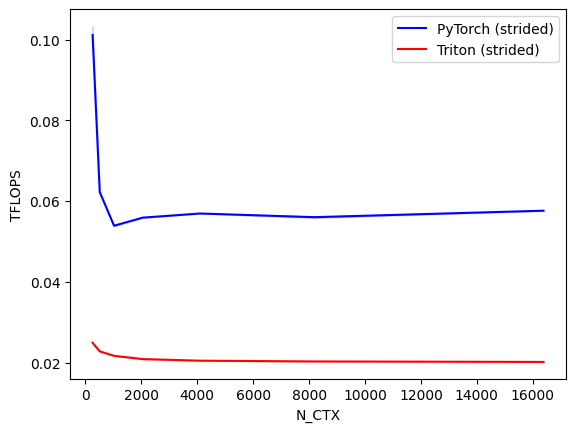

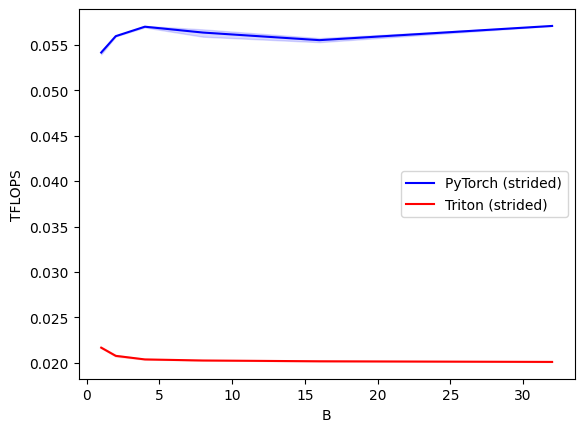

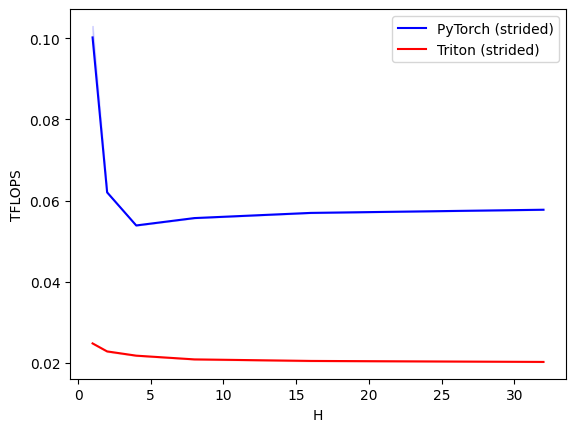

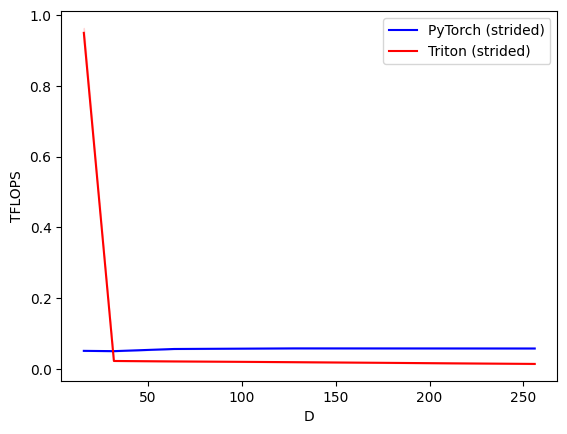

time: 23.7 s (started: 2026-04-02 17:04:22 +00:00)


In [18]:
import math
import torch
import triton
import triton.language as tl
import os


def swa_strided_pytorch(q, k, v, window_sizes: tuple[int, int] = (15, 16)):
    bwd_win_size, fwd_win_size = window_sizes
    win_size = 1 + bwd_win_size + fwd_win_size

    k_to_pad = [k.ravel()]
    v_to_pad = [v.ravel()]
    if bwd_win_size > 0:
        k_to_pad.insert(0, torch.zeros(bwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.insert(0, torch.zeros(bwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))
    if fwd_win_size > 0:
        k_to_pad.append(torch.zeros(fwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.append(torch.zeros(fwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))

    k_strided = torch.as_strided(
        torch.cat(k_to_pad, dim=0),
        size=(*k.shape[:-1], win_size, k.shape[-1]),
        stride=(*k.stride()[:-1], k.stride(-2), k.stride(-1)),
    )
    v_strided = torch.as_strided(
        torch.cat(v_to_pad, dim=0),
        size=(*v.shape[:-1], win_size, v.shape[-1]),
        stride=(*v.stride()[:-1], v.stride(-2), v.stride(-1)),
    )

    row_idx = torch.arange(q.shape[-2], device=q.device).unsqueeze(-1)
    col_idx = torch.arange(-bwd_win_size, fwd_win_size + 1, device=q.device).unsqueeze(-2)
    fwd_inv_mask = row_idx < -col_idx
    bwd_inv_mask = q.shape[-2] - 1 - row_idx < col_idx

    qk = torch.sum(q.unsqueeze(-2) * k_strided, dim=-1) / math.sqrt(q.shape[-1])
    qk_masked = torch.masked_fill(qk, fwd_inv_mask | bwd_inv_mask, -float("inf"))
    a = torch.softmax(qk_masked, dim=-1)
    return torch.sum(a.unsqueeze(-1) * v_strided, dim=-2)


@triton.autotune(
    configs=[
        triton.Config({"BLOCK_M": 32}, num_warps=4),
        triton.Config({"BLOCK_M": 64}, num_warps=4),
        triton.Config({"BLOCK_M": 64}, num_warps=8),
        triton.Config({"BLOCK_M": 128}, num_warps=8),
    ],
    key=["N_CTX"],
)
@triton.jit
def swa_strided_triton_kernel(
    Q, K, V, Out,
    stride_qb, stride_qh, stride_qm, stride_qk,
    stride_kb, stride_kh, stride_km, stride_kk,
    stride_vb, stride_vh, stride_vm, stride_vk,
    stride_ob, stride_oh, stride_om, stride_ok,
    Z, H, N_CTX,
    sm_scale,
    BWD_WINDOW: tl.constexpr,
    FWD_WINDOW: tl.constexpr,
    BLOCK_M: tl.constexpr,
    WIN_SIZE: tl.constexpr,
    BLOCK_DMODEL: tl.constexpr,
):
    start_m = tl.program_id(0)
    off_hz = tl.program_id(1)
    off_b = off_hz // H
    off_h = off_hz % H

    q_offset = off_b * stride_qb + off_h * stride_qh
    k_offset = off_b * stride_kb + off_h * stride_kh
    v_offset = off_b * stride_vb + off_h * stride_vh
    o_offset = off_b * stride_ob + off_h * stride_oh

    offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_d = tl.arange(0, BLOCK_DMODEL)
    offs_w = tl.arange(0, WIN_SIZE) - BWD_WINDOW

    # Load Q as fp32
    q_ptrs = Q + q_offset + offs_m[:, None] * stride_qm + offs_d[None, :] * stride_qk
    q_mask = offs_m[:, None] < N_CTX
    q = tl.load(q_ptrs, mask=q_mask, other=0.0).to(tl.float32)

    # Compute window positions
    kv_pos = offs_m[:, None] + offs_w[None, :]
    in_seq = (kv_pos >= 0) & (kv_pos < N_CTX)
    kv_pos_safe = tl.where(in_seq, kv_pos, 0)

    # Load K as fp32
    k_ptrs = (K + k_offset
              + kv_pos_safe[:, :, None] * stride_km
              + offs_d[None, None, :] * stride_kk)
    k_mask = in_seq[:, :, None]
    k_win = tl.load(k_ptrs, mask=k_mask, other=0.0).to(tl.float32)

    # Load V as fp32
    v_ptrs = (V + v_offset
              + kv_pos_safe[:, :, None] * stride_vm
              + offs_d[None, None, :] * stride_vk)
    v_win = tl.load(v_ptrs, mask=k_mask, other=0.0).to(tl.float32)

    # Attention scores in fp32
    qk = tl.sum(q[:, None, :] * k_win, axis=2)
    qk = qk * sm_scale
    qk = tl.where(in_seq, qk, -float("inf"))

    # Softmax in fp32
    m_i = tl.max(qk, axis=1)
    m_safe = tl.where(m_i == -float("inf"), 0.0, m_i)
    p = tl.exp(qk - m_safe[:, None])
    p = tl.where(in_seq, p, 0.0)
    l_i = tl.sum(p, axis=1)

    # Accumulate in fp32
    acc = tl.sum(p[:, :, None] * v_win, axis=1)
    acc = acc / l_i[:, None]

    # Store as fp32
    o_ptrs = Out + o_offset + offs_m[:, None] * stride_om + offs_d[None, :] * stride_ok
    tl.store(o_ptrs, acc.to(tl.float32), mask=q_mask)


def swa_strided_triton(q, k, v, bwd_window, fwd_window):
    B, H, N, D = q.shape
    out = torch.empty(B, H, N, D, device=q.device, dtype=torch.float32)
    sm_scale = 1.0 / math.sqrt(D)
    win_size = 1 + bwd_window + fwd_window
    WIN_SIZE_POW2 = triton.next_power_of_2(win_size)
    BLOCK_DMODEL = triton.next_power_of_2(D)

    grid = lambda META: (triton.cdiv(N, META["BLOCK_M"]), B * H)

    swa_strided_triton_kernel[grid](
        q, k, v, out,
        *q.stride(), *k.stride(), *v.stride(), *out.stride(),
        B, H, N,
        sm_scale,
        BWD_WINDOW=bwd_window,
        FWD_WINDOW=fwd_window,
        WIN_SIZE=WIN_SIZE_POW2,
        BLOCK_DMODEL=BLOCK_DMODEL,
    )
    return out


SAVE_DIR = "bench_results_full"
DTYPE = torch.float32
DEVICE = "cuda"
QUANTILES = [0.5, 0.2, 0.8]

PROVIDERS = ["pytorch", "triton_strided"]
NAMES     = ["PyTorch (strided)", "Triton (strided)"]
STYLES    = [("blue", "-"), ("red", "-")]


def swa_flops(B, H, N, D, W):
    """
    FLOPs for sliding window attention.
      QK:  each of N queries dots with W keys of dim D  -> 2*N*W*D  (mul + add)
      PV:  each of N queries weighted-sums W values of dim D -> 2*N*W*D
      Total per head per batch = 4*N*W*D
    """
    return B * H * 4 * N * W * D


def ms_to_tflops(ms, flops):
    """Convert milliseconds to TFLOPS given total flop count."""
    return flops / (ms * 1e-3) / 1e12


def run_one(provider, q, k, v, bwd, fwd):
    if provider == "pytorch":
        fn = lambda: swa_strided_pytorch(q, k, v, window_sizes=(bwd, fwd))
    else:
        fn = lambda: swa_strided_triton(q, k, v, bwd, fwd)
    return triton.testing.do_bench(fn, quantiles=QUANTILES)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N_CTX"],
        x_vals=[2**i for i in range(8, 15)],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_seq_len_tflops_fp32",
        args={"B": 2, "H": 8, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_seq_len(N_CTX, provider, B, H, D, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["B"],
        x_vals=[1, 2, 4, 8, 16, 32],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_batch_size_tflops_fp32",
        args={"N_CTX": 2048, "H": 8, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_batch(B, provider, N_CTX, H, D, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["H"],
        x_vals=[1, 2, 4, 8, 16, 32],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_num_heads_tflops_fp32",
        args={"B": 2, "N_CTX": 2048, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_heads(H, provider, B, N_CTX, D, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["D"],
        x_vals=[16, 32, 64, 128, 256],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_head_dim_tflops_fp32",
        args={"B": 2, "H": 8, "N_CTX": 2048, "BWD": 15, "FWD": 16},
    )
)
def bench_head_dim(D, provider, B, H, N_CTX, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["WIN_HALF"],
        x_vals=[4, 8, 16, 32, 64, 128, 256],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_window_size_tflops_fp32",
        args={"B": 2, "H": 8, "N_CTX": 4096, "D": 64},
    )
)
def bench_window(WIN_HALF, provider, B, H, N_CTX, D):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, WIN_HALF, WIN_HALF)
    W = 1 + 2 * WIN_HALF
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


if __name__ == "__main__":
    os.makedirs(SAVE_DIR, exist_ok=True)
    gpu_name = torch.cuda.get_device_name(0)

    print("=" * 70)
    print(f"  SWA Strided — Full Dimension Sweep (TFLOPS, FP32 only)")
    print(f"  GPU: {gpu_name}    dtype: {DTYPE}")
    print("=" * 70)

    benchmarks = [
        ("Sequence Length", bench_seq_len),
        ("Batch Size",      bench_batch),
        ("Number of Heads", bench_heads),
        ("Head Dimension",  bench_head_dim),
        # ("Window Size",     bench_window),
    ]

    for name, bench_fn in benchmarks:
        print(f"\n{'─'*70}")
        print(f"  Sweep: {name}")
        print(f"{'─'*70}")
        bench_fn.run(print_data=True, save_path=SAVE_DIR)

    print(f"\nAll plots saved to {SAVE_DIR}/")

### FP16

  SWA Strided — Full Dimension Sweep (TFLOPS, FP16)
  GPU: NVIDIA L4    dtype: torch.float16

──────────────────────────────────────────────────────────────────────
  Sweep: Sequence Length
──────────────────────────────────────────────────────────────────────
sweep_seq_len_tflops_fp16:
     N_CTX  PyTorch (strided)  Triton (strided)
0    256.0           0.142470          0.211406
1    512.0           0.147272          0.315077
2   1024.0           0.101843          0.416763
3   2048.0           0.095169          0.523242
4   4096.0           0.096857          0.599186
5   8192.0           0.096804          0.657002
6  16384.0           0.093203          0.572523

──────────────────────────────────────────────────────────────────────
  Sweep: Batch Size
──────────────────────────────────────────────────────────────────────
sweep_batch_size_tflops_fp16:
      B  PyTorch (strided)  Triton (strided)
0   1.0           0.101964          0.410884
1   2.0           0.097815          0.517049


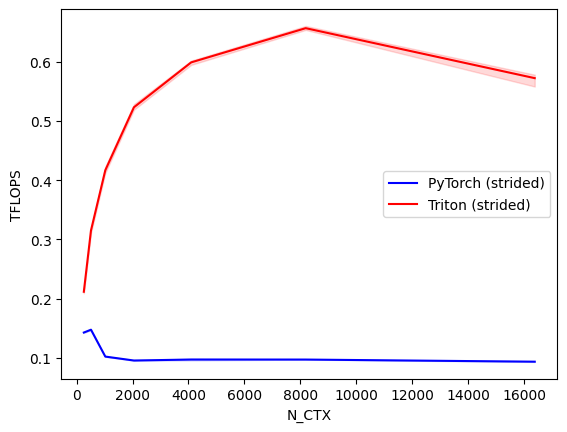

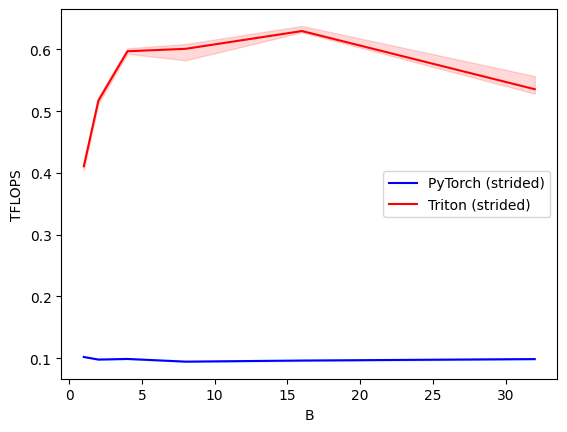

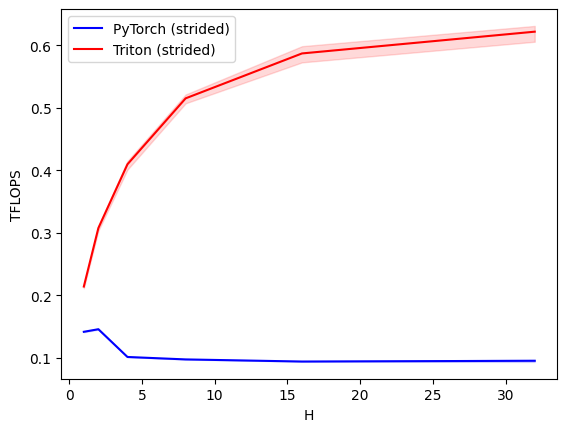

time: 10.7 s (started: 2026-03-28 14:32:28 +00:00)


In [65]:
import math
import torch
import triton
import triton.language as tl
import os


def swa_strided_pytorch(q, k, v, window_sizes: tuple[int, int] = (15, 16)):
    bwd_win_size, fwd_win_size = window_sizes
    win_size = 1 + bwd_win_size + fwd_win_size

    k_to_pad = [k.ravel()]
    v_to_pad = [v.ravel()]
    if bwd_win_size > 0:
        k_to_pad.insert(0, torch.zeros(bwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.insert(0, torch.zeros(bwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))
    if fwd_win_size > 0:
        k_to_pad.append(torch.zeros(fwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.append(torch.zeros(fwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))

    k_strided = torch.as_strided(
        torch.cat(k_to_pad, dim=0),
        size=(*k.shape[:-1], win_size, k.shape[-1]),
        stride=(*k.stride()[:-1], k.stride(-2), k.stride(-1)),
    )
    v_strided = torch.as_strided(
        torch.cat(v_to_pad, dim=0),
        size=(*v.shape[:-1], win_size, v.shape[-1]),
        stride=(*v.stride()[:-1], v.stride(-2), v.stride(-1)),
    )

    row_idx = torch.arange(q.shape[-2], device=q.device).unsqueeze(-1)
    col_idx = torch.arange(-bwd_win_size, fwd_win_size + 1, device=q.device).unsqueeze(-2)
    fwd_inv_mask = row_idx < -col_idx
    bwd_inv_mask = q.shape[-2] - 1 - row_idx < col_idx

    qk = torch.sum(q.unsqueeze(-2) * k_strided, dim=-1) / math.sqrt(q.shape[-1])
    qk_masked = torch.masked_fill(qk, fwd_inv_mask | bwd_inv_mask, -float("inf"))
    a = torch.softmax(qk_masked, dim=-1)
    return torch.sum(a.unsqueeze(-1) * v_strided, dim=-2)


@triton.autotune(
    configs=[
        triton.Config({"BLOCK_M": 32}, num_warps=4),
        triton.Config({"BLOCK_M": 64}, num_warps=4),
        triton.Config({"BLOCK_M": 64}, num_warps=8),
        triton.Config({"BLOCK_M": 128}, num_warps=8),
    ],
    key=["N_CTX"],
)
@triton.jit
def swa_strided_triton_kernel(
    Q, K, V, Out,
    stride_qb, stride_qh, stride_qm, stride_qk,
    stride_kb, stride_kh, stride_km, stride_kk,
    stride_vb, stride_vh, stride_vm, stride_vk,
    stride_ob, stride_oh, stride_om, stride_ok,
    Z, H, N_CTX,
    sm_scale,
    BWD_WINDOW: tl.constexpr,
    FWD_WINDOW: tl.constexpr,
    BLOCK_M: tl.constexpr,
    WIN_SIZE: tl.constexpr,
    BLOCK_DMODEL: tl.constexpr,
):
    start_m = tl.program_id(0)
    off_hz = tl.program_id(1)
    off_b = off_hz // H
    off_h = off_hz % H

    q_offset = off_b * stride_qb + off_h * stride_qh
    k_offset = off_b * stride_kb + off_h * stride_kh
    v_offset = off_b * stride_vb + off_h * stride_vh
    o_offset = off_b * stride_ob + off_h * stride_oh

    offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_d = tl.arange(0, BLOCK_DMODEL)
    offs_w = tl.arange(0, WIN_SIZE) - BWD_WINDOW

    # Load Q as fp16 (native)
    q_ptrs = Q + q_offset + offs_m[:, None] * stride_qm + offs_d[None, :] * stride_qk
    q_mask = offs_m[:, None] < N_CTX
    q = tl.load(q_ptrs, mask=q_mask, other=0.0)  # fp16

    # Compute window positions
    kv_pos = offs_m[:, None] + offs_w[None, :]
    in_seq = (kv_pos >= 0) & (kv_pos < N_CTX)
    kv_pos_safe = tl.where(in_seq, kv_pos, 0)

    # Load K as fp16 (native)
    k_ptrs = (K + k_offset
              + kv_pos_safe[:, :, None] * stride_km
              + offs_d[None, None, :] * stride_kk)
    k_mask = in_seq[:, :, None]
    k_win = tl.load(k_ptrs, mask=k_mask, other=0.0)  # fp16

    # Load V as fp16 (native)
    v_ptrs = (V + v_offset
              + kv_pos_safe[:, :, None] * stride_vm
              + offs_d[None, None, :] * stride_vk)
    v_win = tl.load(v_ptrs, mask=k_mask, other=0.0)  # fp16

    # QK dot product — promote to fp32 for numerical stability
    qk = tl.sum(q[:, None, :].to(tl.float32) * k_win.to(tl.float32), axis=2)
    qk = qk * sm_scale
    qk = tl.where(in_seq, qk, -float("inf"))

    # Softmax in fp32 for stability
    m_i = tl.max(qk, axis=1)
    m_safe = tl.where(m_i == -float("inf"), 0.0, m_i)
    p = tl.exp(qk - m_safe[:, None])
    p = tl.where(in_seq, p, 0.0)
    l_i = tl.sum(p, axis=1)

    # Weighted sum: p is fp32, v_win promoted to fp32 for accumulation
    acc = tl.sum(p[:, :, None] * v_win.to(tl.float32), axis=1)
    acc = acc / l_i[:, None]

    # Store as fp16
    o_ptrs = Out + o_offset + offs_m[:, None] * stride_om + offs_d[None, :] * stride_ok
    tl.store(o_ptrs, acc.to(tl.float16), mask=q_mask)


def swa_strided_triton(q, k, v, bwd_window, fwd_window):
    B, H, N, D = q.shape
    out = torch.empty(B, H, N, D, device=q.device, dtype=torch.float16)
    sm_scale = 1.0 / math.sqrt(D)
    win_size = 1 + bwd_window + fwd_window
    WIN_SIZE_POW2 = triton.next_power_of_2(win_size)
    BLOCK_DMODEL = triton.next_power_of_2(D)

    grid = lambda META: (triton.cdiv(N, META["BLOCK_M"]), B * H)

    swa_strided_triton_kernel[grid](
        q, k, v, out,
        *q.stride(), *k.stride(), *v.stride(), *out.stride(),
        B, H, N,
        sm_scale,
        BWD_WINDOW=bwd_window,
        FWD_WINDOW=fwd_window,
        WIN_SIZE=WIN_SIZE_POW2,
        BLOCK_DMODEL=BLOCK_DMODEL,
    )
    return out


SAVE_DIR = "bench_results_fp16"
DTYPE = torch.float16
DEVICE = "cuda"
QUANTILES = [0.5, 0.2, 0.8]

PROVIDERS = ["pytorch", "triton_strided"]
NAMES     = ["PyTorch (strided)", "Triton (strided)"]
STYLES    = [("blue", "-"), ("red", "-")]


def swa_flops(B, H, N, D, W):
    """
    FLOPs for sliding window attention.
      QK:  each of N queries dots with W keys of dim D  -> 2*N*W*D  (mul + add)
      PV:  each of N queries weighted-sums W values of dim D -> 2*N*W*D
      Total per head per batch = 4*N*W*D
    """
    return B * H * 4 * N * W * D


def ms_to_tflops(ms, flops):
    """Convert milliseconds to TFLOPS given total flop count."""
    return flops / (ms * 1e-3) / 1e12


def run_one(provider, q, k, v, bwd, fwd):
    if provider == "pytorch":
        fn = lambda: swa_strided_pytorch(q, k, v, window_sizes=(bwd, fwd))
    else:
        fn = lambda: swa_strided_triton(q, k, v, bwd, fwd)
    return triton.testing.do_bench(fn, quantiles=QUANTILES)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N_CTX"],
        x_vals=[2**i for i in range(8, 15)],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_seq_len_tflops_fp16",
        args={"B": 2, "H": 8, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_seq_len(N_CTX, provider, B, H, D, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["B"],
        x_vals=[1, 2, 4, 8, 16, 32],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_batch_size_tflops_fp16",
        args={"N_CTX": 2048, "H": 8, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_batch(B, provider, N_CTX, H, D, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["H"],
        x_vals=[1, 2, 4, 8, 16, 32],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_num_heads_tflops_fp16",
        args={"B": 2, "N_CTX": 2048, "D": 64, "BWD": 15, "FWD": 16},
    )
)
def bench_heads(H, provider, B, N_CTX, D, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["D"],
        x_vals=[16, 32, 64, 128, 256],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_head_dim_tflops_fp16",
        args={"B": 2, "H": 8, "N_CTX": 2048, "BWD": 15, "FWD": 16},
    )
)
def bench_head_dim(D, provider, B, H, N_CTX, BWD, FWD):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, BWD, FWD)
    W = 1 + BWD + FWD
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["WIN_HALF"],
        x_vals=[4, 8, 16, 32, 64, 128, 256],
        line_arg="provider",
        line_vals=PROVIDERS,
        line_names=NAMES,
        styles=STYLES,
        ylabel="TFLOPS",
        plot_name="sweep_window_size_tflops_fp16",
        args={"B": 2, "H": 8, "N_CTX": 4096, "D": 64},
    )
)
def bench_window(WIN_HALF, provider, B, H, N_CTX, D):
    q = torch.randn(B, H, N_CTX, D, device=DEVICE, dtype=DTYPE)
    k, v = torch.randn_like(q), torch.randn_like(q)
    ms, min_ms, max_ms = run_one(provider, q, k, v, WIN_HALF, WIN_HALF)
    W = 1 + 2 * WIN_HALF
    flops = swa_flops(B, H, N_CTX, D, W)
    return ms_to_tflops(ms, flops), ms_to_tflops(max_ms, flops), ms_to_tflops(min_ms, flops)


if __name__ == "__main__":
    os.makedirs(SAVE_DIR, exist_ok=True)
    gpu_name = torch.cuda.get_device_name(0)

    print("=" * 70)
    print(f"  SWA Strided — Full Dimension Sweep (TFLOPS, FP16)")
    print(f"  GPU: {gpu_name}    dtype: {DTYPE}")
    print("=" * 70)

    benchmarks = [
        ("Sequence Length", bench_seq_len),
        ("Batch Size",      bench_batch),
        ("Number of Heads", bench_heads),
    ]

    for name, bench_fn in benchmarks:
        print(f"\n{'─'*70}")
        print(f"  Sweep: {name}")
        print(f"{'─'*70}")
        bench_fn.run(print_data=True, save_path=SAVE_DIR)

    print(f"\nAll plots saved to {SAVE_DIR}/")

### SDPA

In [19]:
import math
import torch
import torch.nn.functional as F


def swa_sdpa_strided(q, k, v, window_sizes: tuple[int, int] = (15, 16)):
    """
    Sliding window attention using PyTorch SDPA with strided K/V windows.

    The strided trick reshapes K and V into (B, H, N, W, D) windows via
    as_strided, then each query position is treated as an independent
    batch element with L=1 query attending to S=W keys.  The actual
    dot-product / softmax / value-aggregation is handed off to
    F.scaled_dot_product_attention, which can dispatch to the
    memory-efficient or math backend automatically.

    Parameters
    ----------
    q : (B, H, N, D) torch.Tensor
    k : (B, H, N, D) torch.Tensor
    v : (B, H, N, D) torch.Tensor
    window_sizes : (bwd, fwd)
        Number of past / future positions each query can attend to.
        Causal masking when fwd == 0.

    Returns
    -------
    out : (B, H, N, D) torch.Tensor
    """
    bwd_win, fwd_win = window_sizes
    win_size = 1 + bwd_win + fwd_win
    B, H, N, D = q.shape
    assert win_size <= N, "window must not exceed sequence length"

    # Pad along the sequence (dim=-2) so that boundary positions have
    # zero-filled neighbours instead of out-of-bounds reads.
    k_padded = F.pad(k, (0, 0, bwd_win, fwd_win))  # (B, H, N+W-1, D)
    v_padded = F.pad(v, (0, 0, bwd_win, fwd_win))

    # as_strided view: (B, H, N, W, D)
    # Each position i sees k_padded[:, :, i : i+W, :]
    new_shape = (B, H, N, win_size, D)
    new_stride = (
        k_padded.stride(0),
        k_padded.stride(1),
        k_padded.stride(2),   # step one position along the padded seq
        k_padded.stride(2),   # step within the window == same stride
        k_padded.stride(3),
    )
    k_win = torch.as_strided(k_padded, size=new_shape, stride=new_stride).contiguous()
    v_win = torch.as_strided(v_padded, size=new_shape, stride=new_stride).contiguous()

    # Treat (B, H, N) as batch dims ⇒  Q: (B, H, N, 1, D)
    #                                    K: (B, H, N, W, D)
    #                                    V: (B, H, N, W, D)
    q_r = q.unsqueeze(-2)  # (B, H, N, 1, D)

    # For positions near the edges the zero-padding is invalid; mask
    # those entries to -inf so softmax ignores them.
    row_idx = torch.arange(N, device=q.device)                          # (N,)
    win_offsets = torch.arange(-bwd_win, fwd_win + 1, device=q.device)  # (W,)
    abs_pos = row_idx.unsqueeze(-1) + win_offsets.unsqueeze(0)           # (N, W)

    # True where out-of-bounds
    invalid = (abs_pos < 0) | (abs_pos >= N)

    # Shape (N, 1, W) so it broadcasts over (B, H, N, 1, W) attention logits
    attn_bias = torch.zeros(N, 1, win_size, device=q.device, dtype=q.dtype)
    attn_bias.masked_fill_(invalid.unsqueeze(1), float("-inf"))

    # SDPA
    out = F.scaled_dot_product_attention(
        q_r, k_win, v_win,
        attn_mask=attn_bias,
    )
    return out.squeeze(-2)  # (B, H, N, D)


# ---------------------------------------------------------------------------
# Quick smoke-test / correctness check against the manual strided version
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    torch.manual_seed(0)
    B, H, N, D = 2, 4, 128, 64
    q = torch.randn(B, H, N, D, device="cuda", dtype=torch.float32)
    k = torch.randn(B, H, N, D, device="cuda", dtype=torch.float32)
    v = torch.randn(B, H, N, D, device="cuda", dtype=torch.float32)

    for bwd, fwd in [(15, 16), (0, 0), (31, 0), (0, 31), (7, 7)]:
        ref = swa_strided(q, k, v, window_sizes=(bwd, fwd))
        out = swa_sdpa_strided(q, k, v, window_sizes=(bwd, fwd))
        err = (ref - out).abs().max().item()
        print(f"window=({bwd:>2},{fwd:>2})  max-abs-error = {err:.2e}")

window=(15,16)  max-abs-error = 5.96e-07
window=( 0, 0)  max-abs-error = 0.00e+00
window=(31, 0)  max-abs-error = 7.15e-07
window=( 0,31)  max-abs-error = 8.34e-07
window=( 7, 7)  max-abs-error = 5.22e-07
time: 112 ms (started: 2026-04-02 17:14:59 +00:00)


### Flex Attention

In [20]:
import torch
from torch.nn.attention.flex_attention import flex_attention, create_block_mask


# torch.compile is essential for flex_attention performance —
# it fuses the custom mask logic into the attention kernel.
flex_attention_compiled = torch.compile(flex_attention)


def swa_flex(q, k, v, window_sizes: tuple[int, int] = (15, 16)):
    """
    Sliding window attention via torch.nn.attention.flex_attention.

    flex_attention accepts a *mask_mod* that returns True for positions
    the query is allowed to attend to.  create_block_mask converts this
    into a BlockMask that (a) skips entire blocks outside the window
    band and (b) applies element-level masking within partially-valid
    blocks — giving both correctness and block-sparse speed.

    Parameters
    ----------
    q : (B, H, N, D) torch.Tensor
    k : (B, H, N, D) torch.Tensor
    v : (B, H, N, D) torch.Tensor
    window_sizes : (bwd, fwd)
        Number of past / future positions each query can attend to.
        Causal masking when fwd == 0.

    Returns
    -------
    out : (B, H, N, D) torch.Tensor
    """
    bwd_win, fwd_win = window_sizes
    B, H, N, D = q.shape

    # mask_mod signature: (b, h, q_idx, kv_idx) -> bool
    # True  = attend,  False = masked (-inf before softmax)
    def sliding_window(b, h, q_idx, kv_idx):
        return (q_idx - kv_idx <= bwd_win) & (kv_idx - q_idx <= fwd_win)

    block_mask = create_block_mask(
        sliding_window, B=B, H=H, Q_LEN=N, KV_LEN=N, device=q.device,
    )

    return flex_attention_compiled(q, k, v, block_mask=block_mask)


if __name__ == "__main__":
    torch.manual_seed(0)
    B, H, N, D = 2, 4, 128, 64
    q = torch.randn(B, H, N, D, device="cuda", dtype=torch.float32)
    k = torch.randn(B, H, N, D, device="cuda", dtype=torch.float32)
    v = torch.randn(B, H, N, D, device="cuda", dtype=torch.float32)

    for bwd, fwd in [(15, 16), (0, 0), (31, 0), (0, 31), (7, 7)]:
        ref = swa_strided(q, k, v, window_sizes=(bwd, fwd))
        out = swa_flex(q, k, v, window_sizes=(bwd, fwd))
        err = (ref - out).abs().max().item()
        print(f"window=({bwd:>2},{fwd:>2})  max-abs-error = {err:.2e}")

window=(15,16)  max-abs-error = 8.34e-07
window=( 0, 0)  max-abs-error = 0.00e+00
window=(31, 0)  max-abs-error = 9.54e-07
window=( 0,31)  max-abs-error = 7.15e-07
window=( 7, 7)  max-abs-error = 9.54e-07
time: 17.4 s (started: 2026-04-02 17:15:35 +00:00)


### Benchamrk All modules

In [73]:
# TODO(mahdi)

time: 229 μs (started: 2026-03-28 14:59:14 +00:00)


### Flash-Attention

In [ ]:
!pip install flash-attn --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 128.9 MB/s  0:00:00
  Preparing metadata (pyproject.toml) ... done